In [45]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
bidmc = fg.datasets.bidmc(subject=1)

bidmc_oscillation = fg.oscillation.Oscillation(signals="respiration", group="subject", smooth_signal=False, diff_lag=45, eps=0.15)
bidmc_oscillation_features = bidmc_oscillation.fit_transform(bidmc)
bidmc_oscillation_features['index'] = bidmc_oscillation_features.index

sampling_rate = 125

bidmc_oscillation_objects = bidmc_oscillation.summarize(bidmc_oscillation_features, signal="respiration", include_partial=True)

objects = bidmc_oscillation_objects.table
complete = objects.loc[objects["is_complete"]]

assert complete["start_index"].lt(
    complete["peak_index"]
).all()

assert complete["peak_index"].lt(
    complete["end_index"]
).all()

assert complete["temporal_symmetry"].between(
    0,
    1,
).all()

bidmc_accumulation = fg.accumulation.Accumulation(signals='respiration', group='subject')
bidmc_accumulation_features = bidmc_accumulation.fit_transform(bidmc_oscillation_features)
bidmc_accumulation_objects = bidmc_accumulation.summarize(bidmc_accumulation_features, signal='respiration')

(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='respiration'>,
        <Axes: ylabel='respiration_rising\nrespiration_falling'>,
        <Axes: ylabel='respiration_peak\nrespiration_trough'>,
        <Axes: xlabel='Time', ylabel='respiration_wave_id'>], dtype=object))

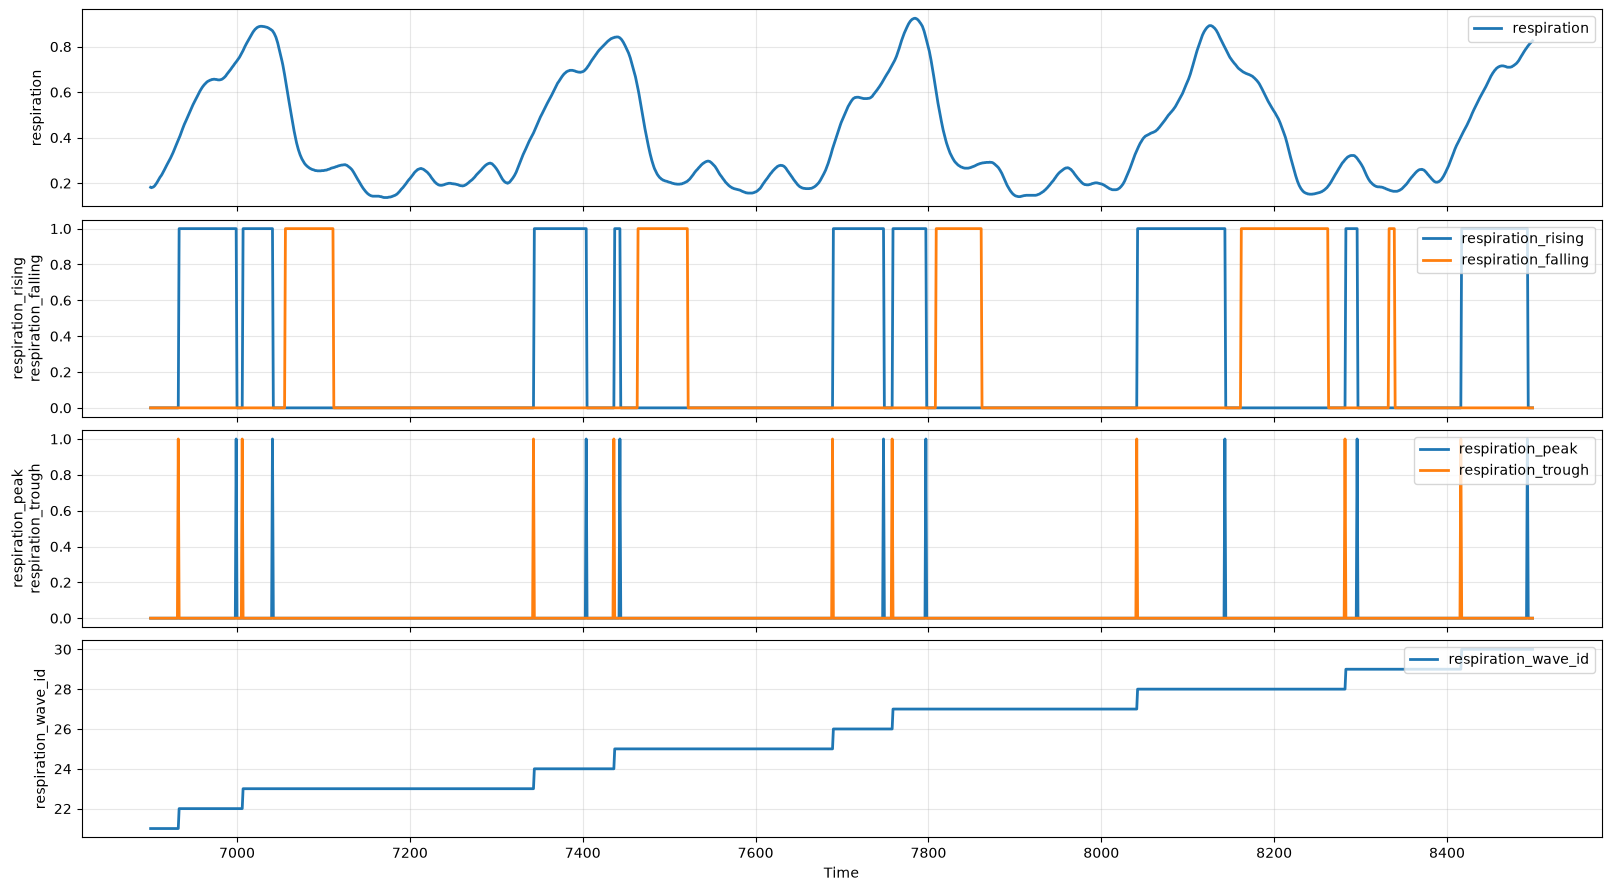

In [47]:
fg.plot(
    bidmc_oscillation_features[6900:8500],
    [
        ["respiration"],
        ["respiration_rising", "respiration_falling"],
        ["respiration_peak", "respiration_trough"],
        ["respiration_wave_id"],
    ],
)

In [48]:
def describe_respiration_objects(
    respiration_objects,
    *,
    subject_label,
    sampling_rate=125,
):
    """
    Render a deterministic natural-language summary from a respiration
    object table.

    Expected columns:
        start_index
        end_index

    Optional columns:
        amplitude
        period
        temporal_symmetry
        is_complete
    """
    if respiration_objects.empty:
        return (
            f"No candidate breath objects were identified "
            f"for {subject_label}."
        )

    objects = respiration_objects.copy()

    if "is_complete" in objects.columns:
        complete = objects.loc[objects["is_complete"]].copy()
    else:
        complete = objects.copy()

    if complete.empty:
        return (
            f"{len(objects)} candidate respiration objects were identified "
            f"for {subject_label}, but none were complete."
        )

    recording_start = int(objects["start_index"].min())
    recording_end = int(objects["end_index"].max())

    duration_samples = recording_end - recording_start + 1
    duration_seconds = duration_samples / sampling_rate
    duration_minutes = duration_seconds / 60

    breath_count = len(complete)
    breaths_per_minute = breath_count / duration_minutes

    sentences = [
        f"{breath_count} complete candidate breath objects were identified "
        f"for {subject_label} over {duration_seconds:.1f} seconds.",
        f"This corresponds to an estimated respiratory rate of "
        f"{breaths_per_minute:.1f} breaths per minute.",
    ]

    if "period" in complete.columns:
        mean_period_samples = complete["period"].dropna().mean()

        if pd.notna(mean_period_samples):
            mean_period_seconds = mean_period_samples / sampling_rate

            sentences.append(
                f"The mean breath period was "
                f"{mean_period_seconds:.2f} seconds."
            )

    if "amplitude" in complete.columns:
        mean_amplitude = complete["amplitude"].dropna().mean()

        if pd.notna(mean_amplitude):
            sentences.append(
                f"The mean candidate breath amplitude was "
                f"{mean_amplitude:.3f}."
            )

    if "temporal_symmetry" in complete.columns:
        mean_symmetry = complete["temporal_symmetry"].dropna().mean()

        if pd.notna(mean_symmetry):
            sentences.append(
                f"The mean temporal symmetry was "
                f"{mean_symmetry:.3f}."
            )

    incomplete_count = len(objects) - len(complete)

    if incomplete_count:
        noun = "object" if incomplete_count == 1 else "objects"

        sentences.append(
            f"{incomplete_count} incomplete respiration {noun} "
            f"were excluded from the rate estimate."
        )

    return " ".join(sentences)

In [49]:
message = describe_respiration_objects(
    bidmc_oscillation_objects.table,
    subject_label="BIDMC subject 1",
    sampling_rate=125,
)

print(message)

175 complete candidate breath objects were identified for BIDMC subject 1 over 476.8 seconds. This corresponds to an estimated respiratory rate of 22.0 breaths per minute. The mean breath period was 2.72 seconds. The mean candidate breath amplitude was 0.442. The mean temporal symmetry was 0.580. 2 incomplete respiration objects were excluded from the rate estimate.
